In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn as sk

In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [4]:
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target

In [5]:
# Разделяем данные на признаки (X) и целевую переменную (y)
# Целевая переменная (MedHouseVal) — это средняя стоимость дома в районе
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Методы машинного обучения

## Линейная регрессия

In [7]:
# Создаем и обучаем модель линейной регрессии
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
# Делаем предсказания на тестовых данных
y_pred = lr_model.predict(X_test)

In [9]:
# Оцениваем качество модели
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [10]:
print(f"Среднеквадратичная ошибка (MSE): {mse:.4f}")
print(f"Среднеабсолютная ошибка (MAE): {mae:.4f}")
print(f"Коэффициент детерминации (R²): {r2:.4f}")

Среднеквадратичная ошибка (MSE): 0.5559
Среднеабсолютная ошибка (MAE): 0.5332
Коэффициент детерминации (R²): 0.5758


## Полиномиальная регрессия

In [11]:
from sklearn.preprocessing import PolynomialFeatures

In [12]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [13]:
PL_model = LinearRegression()
PL_model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
y_pred_pl = PL_model.predict(X_test_poly)

In [15]:
# Оцениваем качество модели
mse = mean_squared_error(y_test, y_pred_pl)
mae = mean_absolute_error(y_test, y_pred_pl)
r2 = r2_score(y_test, y_pred_pl)

In [16]:
print(f"Среднеквадратичная ошибка (MSE): {mse:.4f}")
print(f"Среднеабсолютная ошибка (MAE): {mae:.4f}")
print(f"Коэффициент детерминации (R²): {r2:.4f}")

Среднеквадратичная ошибка (MSE): 0.4643
Среднеабсолютная ошибка (MAE): 0.4670
Коэффициент детерминации (R²): 0.6457


## Деревья решений

In [17]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=10,           # Максимальная глубина дерева
    min_samples_split=20,   # Минимальное количество образцов для разделения узла
    min_samples_leaf=10,    # Минимальное количество образцов в листе
    random_state=42
)

dt_model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [18]:
y_pred_dt = dt_model.predict(X_test)

mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Среднеквадратичная ошибка (MSE): {mse_dt:.4f}")
print(f"Среднеабсолютная ошибка (MAE): {mae_dt:.4f}")
print(f"Коэффициент детерминации (R²): {r2_dt:.4f}")

Среднеквадратичная ошибка (MSE): 0.3785
Среднеабсолютная ошибка (MAE): 0.4197
Коэффициент детерминации (R²): 0.7112


## Случайный лес

In [19]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,       # Количество деревьев
    max_depth=None,         # Максимальная глубина (None - без ограничения)
    min_samples_split=3,     # Минимальное количество объектов в листе
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [20]:
y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Среднеквадратичная ошибка (MSE): {mse_rf:.4f}")
print(f"Среднеабсолютная ошибка (MAE): {mae_rf:.4f}")
print(f"Коэффициент детерминации (R²): {r2_rf:.4f}")

Среднеквадратичная ошибка (MSE): 0.2560
Среднеабсолютная ошибка (MAE): 0.3280
Коэффициент детерминации (R²): 0.8047


## Grid Search для Случайного леса

In [21]:
# Определяем сетку параметров
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [2, 5, 10]
}

In [22]:
# Создаём Grid Search
# grid_search = GridSearchCV(
#     estimator=RandomForestRegressor(random_state=42),
#     param_grid=param_grid
# )

# grid_search.fit(X_train, y_train)

In [23]:
# Лучшие параметры
# print(f"\nЛучшие параметры: {grid_search.best_params_}")

In [24]:
# Проверка на тесте
# best_model = grid_search.best_estimator_
# y_pred = best_model.predict(X_test)

# mse_rf_gs = mean_squared_error(y_test, y_pred)
# mae_rf_gs = mean_absolute_error(y_test, y_pred)
# r2_rf_gs = r2_score(y_test, y_pred)

# print(f"Среднеквадратичная ошибка (MSE): {mse_rf_gs:.4f}")
# print(f"Среднеабсолютная ошибка (MAE): {mae_rf_gs:.4f}")
# print(f"Коэффициент детерминации (R²): {r2_rf_gs:.4f}")

## Метод опорных векторов

In [25]:
from sklearn.svm import SVR

svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_model.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [26]:
y_pred_svr = svr_model.predict(X_test)

mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print(f"Среднеквадратичная ошибка (MSE): {mse_svr:.4f}")
print(f"Среднеабсолютная ошибка (MAE): {mae_svr:.4f}")
print(f"Коэффициент детерминации (R²): {r2_svr:.4f}")

Среднеквадратичная ошибка (MSE): 1.3320
Среднеабсолютная ошибка (MAE): 0.8600
Коэффициент детерминации (R²): -0.0165


## K - ближайших соседей

In [27]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [28]:
y_pred_knn = knn_model.predict(X_test)

mse_knn = mean_squared_error(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print(f"Среднеквадратичная ошибка (MSE): {mse_knn:.4f}")
print(f"Среднеабсолютная ошибка (MAE): {mae_knn:.4f}")
print(f"Коэффициент детерминации (R²): {r2_knn:.4f}")

Среднеквадратичная ошибка (MSE): 1.1187
Среднеабсолютная ошибка (MAE): 0.8128
Коэффициент детерминации (R²): 0.1463


# Градиентный бустинг

## CatBoost

In [29]:
from catboost import CatBoostRegressor

model_cat = CatBoostRegressor(
    iterations=500, 
    learning_rate=0.5, 
    depth=6
)

model_cat.fit(X_train, y_train, eval_set=(X_test, y_test))

predications_cat = model_cat.predict(X_test)

0:	learn: 0.8733939	test: 0.8757100	best: 0.8757100 (0)	total: 149ms	remaining: 1m 14s
1:	learn: 0.7369514	test: 0.7510252	best: 0.7510252 (1)	total: 152ms	remaining: 37.8s
2:	learn: 0.6802804	test: 0.6977558	best: 0.6977558 (2)	total: 154ms	remaining: 25.6s
3:	learn: 0.6301843	test: 0.6499228	best: 0.6499228 (3)	total: 157ms	remaining: 19.4s
4:	learn: 0.6110106	test: 0.6329877	best: 0.6329877 (4)	total: 159ms	remaining: 15.7s
5:	learn: 0.5925113	test: 0.6154343	best: 0.6154343 (5)	total: 161ms	remaining: 13.3s
6:	learn: 0.5746111	test: 0.5965814	best: 0.5965814 (6)	total: 164ms	remaining: 11.5s
7:	learn: 0.5685661	test: 0.5914530	best: 0.5914530 (7)	total: 166ms	remaining: 10.2s
8:	learn: 0.5607250	test: 0.5855954	best: 0.5855954 (8)	total: 168ms	remaining: 9.17s
9:	learn: 0.5509236	test: 0.5758530	best: 0.5758530 (9)	total: 170ms	remaining: 8.35s
10:	learn: 0.5443628	test: 0.5706328	best: 0.5706328 (10)	total: 173ms	remaining: 7.67s
11:	learn: 0.5375454	test: 0.5642200	best: 0.564220

In [30]:
mse_cat = mean_squared_error(y_test, predications_cat)
mae_cat = mean_absolute_error(y_test, predications_cat)
r2_cat = r2_score(y_test, predications_cat)

print(f"Среднеквадратичная ошибка (MSE): {mse_cat:.4f}")
print(f"Среднеабсолютная ошибка (MAE): {mae_cat:.4f}")
print(f"Коэффициент детерминации (R²): {r2_cat:.4f}")

Среднеквадратичная ошибка (MSE): 0.2033
Среднеабсолютная ошибка (MAE): 0.2987
Коэффициент детерминации (R²): 0.8448


## XGBoost

In [31]:
import xgboost as xgb

model_xg = xgb.XGBRegressor(
    n_estimators=500, 
    learning_rate = 0.5,
    max_depth = 6
)

model_xg.fit(X_train, y_train)

predications_xg = model_xg.predict(X_test)

In [32]:
mse_xg = mean_squared_error(y_test, predications_xg)
mae_xg = mean_absolute_error(y_test, predications_xg)
r2_xg = r2_score(y_test, predications_xg)

print(f"Среднеквадратичная ошибка (MSE): {mse_xg:.4f}")
print(f"Среднеабсолютная ошибка (MAE): {mae_xg:.4f}")
print(f"Коэффициент детерминации (R²): {r2_xg:.4f}")

Среднеквадратичная ошибка (MSE): 0.2464
Среднеабсолютная ошибка (MAE): 0.3315
Коэффициент детерминации (R²): 0.8120


## LigthGBM

In [33]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=500, 
    learning_rate = 0.5,
    max_depth = 6
)

lgb_model.fit(X_train, y_train)

predications_lgb = lgb_model.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000438 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [34]:
mse_lgb = mean_squared_error(y_test, predications_lgb)
mae_lgb = mean_absolute_error(y_test, predications_lgb)
r2_lgb = r2_score(y_test, predications_lgb)

print(f"Среднеквадратичная ошибка (MSE): {mse_lgb:.4f}")
print(f"Среднеабсолютная ошибка (MAE): {mae_lgb:.4f}")
print(f"Коэффициент детерминации (R²): {r2_lgb:.4f}")

Среднеквадратичная ошибка (MSE): 0.2311
Среднеабсолютная ошибка (MAE): 0.3281
Коэффициент детерминации (R²): 0.8236


# Методы глубокого обучения

In [35]:
from fastai.tabular.all import *
import torch.nn.functional as F

c:\Users\dimam\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## MLP

In [38]:
# Оставляем только числовые признаки
dep_var = 'MedHouseVal'
cont_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 
              'Population', 'Latitude', 'Longitude']

# Логарифмирование целевой переменной (для стабильности обучения)
df[dep_var] = np.log1p(df[dep_var])

# Разделение на train/valid
splits = RandomSplitter(valid_pct=0.2, seed=42)(range_of(df))

# TabularPandas без категориальных признаков
to = TabularPandas(
    df,
    procs=[FillMissing, Normalize],
    cat_names=[],           # пустой список
    cont_names=cont_names,
    y_names=dep_var,
    splits=splits
)

dls = to.dataloaders(bs=64)
print(f"Количество непрерывных признаков: {len(dls.cont_names)}")

Количество непрерывных признаков: 7


<div></div>

epoch,train_loss,valid_loss,_rmse,mae,r2_score,time
0,0.042802,0.020846,0.144380,0.107205,0.478745,00:01
1,0.017867,0.017007,0.130411,0.101088,0.098058,00:01
2,0.013785,0.014626,0.120940,0.090802,0.592629,00:01
3,0.013644,0.012380,0.111266,0.087656,0.448594,00:01
4,0.011792,0.012103,0.110015,0.086223,-0.083724,00:01
5,0.010630,0.009318,0.096531,0.072521,0.580337,00:01
6,0.009628,0.009375,0.096824,0.073885,0.456734,00:01
7,0.009616,0.008382,0.091553,0.069300,0.608104,00:01
8,0.009642,0.008736,0.093464,0.071988,0.591745,00:01
9,0.008582,0.008112,0.090068,0.069257,0.622411,00:01


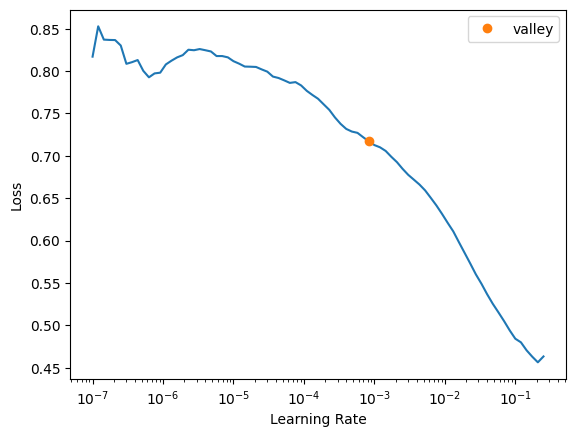

In [39]:
learn_mlp = tabular_learner(
    dls,
    layers=[200, 100],       # два скрытых слоя
    metrics=[rmse, mae, r2_score],
    y_range=None
)

learn_mlp.lr_find()
learn_mlp.fit_one_cycle(20, lr_max=1e-2)

## TabNet